# Feature Engineering

Этот ноутбук позволяет проводить эксперименты по генерации признаков. Можно менять параметры отбора, добавлять или исключать блоки данных.

In [6]:
import sys
import os
import pandas as pd
import logging
import matplotlib.pyplot as plt
import seaborn as sns

# Путь к src
sys.path.append(os.path.abspath('..'))

from src.features.pipeline import FeatureEngineeringPipeline

# Настройки
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)


## 1. Конфигурация эксперимента

In [7]:
EXP_PARAMS = {
    "top_n_features": 250,        # Сколько признаков оставить после Ridge
    "use_cache": True,            # Использовать ли предобработанные .parquet
    "ridge_alpha": 1.0            # Регуляризация в Ridge
}

## 2. Запуск пайплайна с кастомными параметрами

In [8]:
class ExperimentalPipeline(FeatureEngineeringPipeline):
    """Подкласс для быстрой модификации поведения пайплайна без правки исходников"""
    def _select_features_ridge(self, df, top_n=None):
        # Значение из EXP_PARAMS
        target_n = EXP_PARAMS["top_n_features"]
        return super()._select_features_ridge(df, top_n=target_n)

pipeline = ExperimentalPipeline(
    use_cache=EXP_PARAMS["use_cache"],
)

# Запуск FE
final_df = pipeline.run()

2026-05-05 01:22:02,440 | INFO | src.data.loader | Loading from cache | table=application_train
2026-05-05 01:22:02,809 | INFO | src.data.loader | Loading from cache | table=application_test
2026-05-05 01:22:02,845 | INFO | src.data.loader | Loading from cache | table=bureau
2026-05-05 01:22:03,043 | INFO | src.data.loader | Loading from cache | table=bureau_balance
2026-05-05 01:22:03,597 | INFO | src.data.loader | Loading from cache | table=previous_application
2026-05-05 01:22:04,298 | INFO | src.data.loader | Loading from cache | table=installments_payments
2026-05-05 01:22:05,046 | INFO | src.data.loader | Loading from cache | table=POS_CASH_balance
2026-05-05 01:22:05,559 | INFO | src.data.loader | Loading from cache | table=credit_card_balance
2026-05-05 01:22:08,992 | INFO | src.data.preprocessor | Categorical features label-encoded: 16 columns
2026-05-05 01:22:09,941 | INFO | src.data.preprocessor | Preprocessing Bureau...
2026-05-05 01:22:10,474 | INFO | src.data.preprocessor

## 3. Анализ важности признаков
Посмотрим какие признаки оказались самыми полезными

2026-05-05 01:23:46,256 | INFO | __main__ | Loading feature importance analysis
2026-05-05 01:23:46,265 | INFO | __main__ | Loaded 476 features
2026-05-05 01:23:46,265 | INFO | __main__ | Building feature importance plot


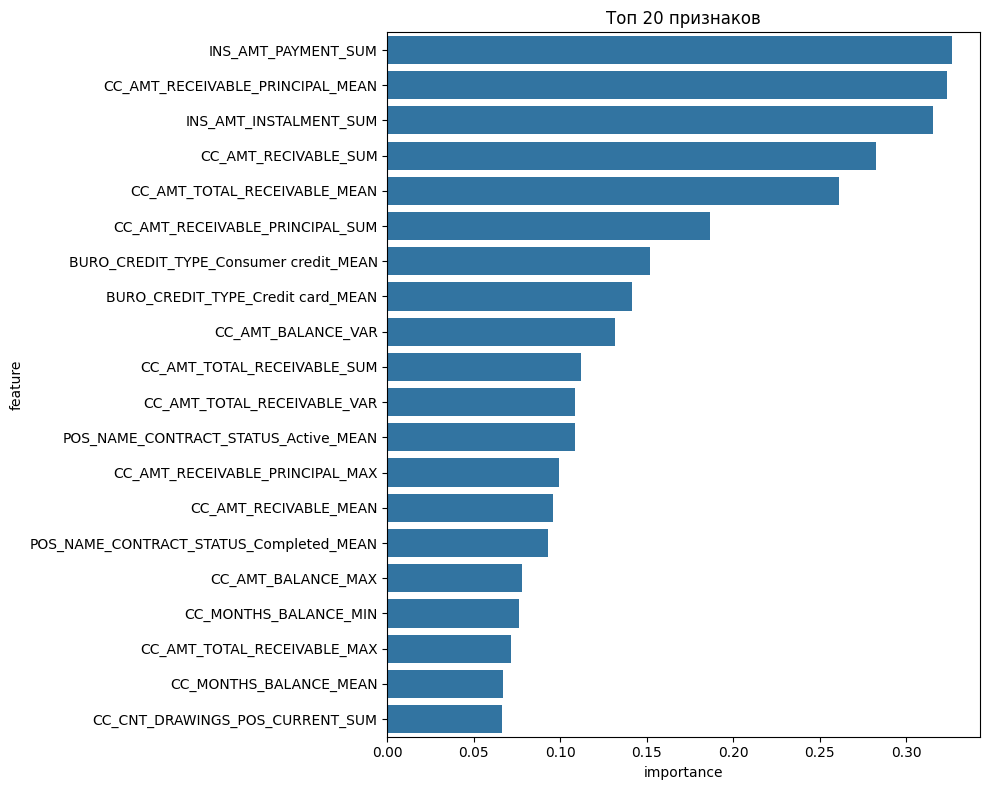

In [9]:
logger.info("Loading feature importance analysis")
importance_df = pd.read_csv('../data/processed/feature_importance.csv')
logger.info(f"Loaded {len(importance_df)} features")

logger.info("Building feature importance plot")
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))
plt.title(f"Топ 20 признаков")
plt.tight_layout()
plt.show()

## 4. Проверка корреляций
Убедимся, что отобранные признаки не слишком сильно коррелируют между собой

2026-05-05 01:23:46,472 | INFO | __main__ | Starting correlation analysis for top 15 features
2026-05-05 01:23:46,472 | INFO | __main__ | Analyzing correlations for: INS_AMT_PAYMENT_SUM, CC_AMT_RECEIVABLE_PRINCIPAL_MEAN, INS_AMT_INSTALMENT_SUM, CC_AMT_RECIVABLE_SUM, CC_AMT_TOTAL_RECEIVABLE_MEAN, CC_AMT_RECEIVABLE_PRINCIPAL_SUM, BURO_CREDIT_TYPE_Consumer credit_MEAN, BURO_CREDIT_TYPE_Credit card_MEAN, CC_AMT_BALANCE_VAR, CC_AMT_TOTAL_RECEIVABLE_SUM, CC_AMT_TOTAL_RECEIVABLE_VAR, POS_NAME_CONTRACT_STATUS_Active_MEAN, CC_AMT_RECEIVABLE_PRINCIPAL_MAX, CC_AMT_RECIVABLE_MEAN, POS_NAME_CONTRACT_STATUS_Completed_MEAN
2026-05-05 01:23:46,636 | INFO | __main__ | Correlation matrix computed


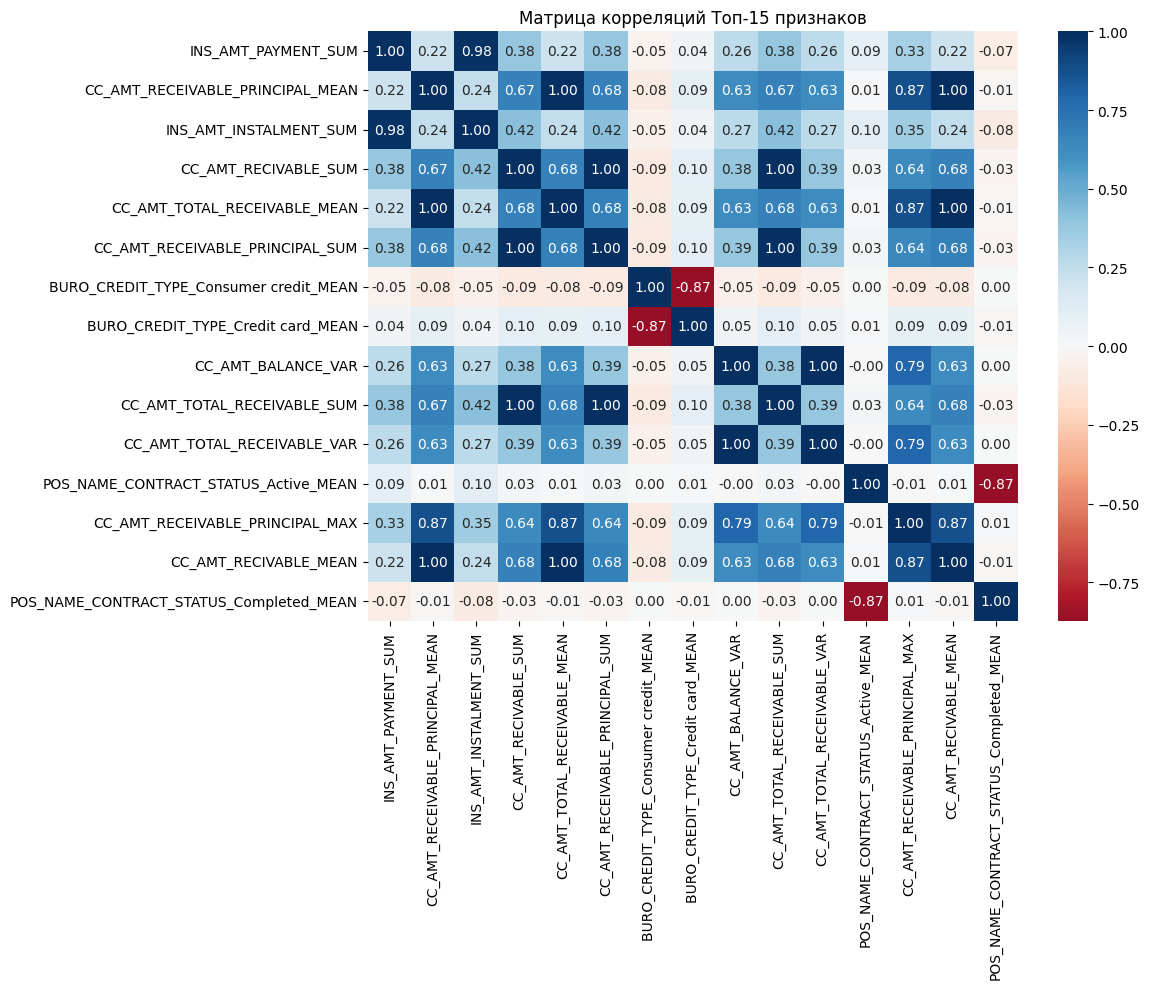

In [10]:
logger.info("Starting correlation analysis for top 15 features")
top_features = importance_df['feature'].head(15).tolist()
logger.info(f"Analyzing correlations for: {', '.join(top_features)}")

corr_matrix = final_df[top_features].corr()
logger.info("Correlation matrix computed")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title("Матрица корреляций Топ-15 признаков")
plt.tight_layout()
plt.show()

Запускаем в терминале `mlflow ui --backend-store-uri sqlite:///mlflow.db`